In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

In [64]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
global_path = "/content/drive/MyDrive/project3/X_Global.npy"
local_path = "/content/drive/MyDrive/project3/X_Local.npy"
y_path = "/content/drive/MyDrive/project3/metadata_final.csv"

#get y from metadata_final.csv
df = pd.read_csv(y_path)
y = df['label'].values.astype(np.float32)

In [66]:
print(f"global data shape = {np.load(global_path).shape}")
print(f"local data shape = {np.load(local_path).shape}")
print(f"y shape = {y.shape}")

global data shape = (740, 2001)
local data shape = (740, 201)
y shape = (740,)


In [67]:
#light curve data need to change to adjust local and global data
#we have local and global data for each star, X_Global.npy and X_Local.npy
class LightCurveDataset(Dataset):
    def __init__(self, global_path, local_path, y):
        self.global_x = np.load(global_path)
        self.local_x = np.load(local_path)
        self.local_x = self.local_x.reshape(-1, 1, self.local_x.shape[1]).astype(np.float32)
        self.global_x = self.global_x.reshape(-1, 1, self.global_x.shape[1]).astype(np.float32)
        self.y = y.astype(np.float32)

        #check if the size of data is same
        assert len(self.global_x) == len(self.local_x) == len(self.y), "The size of data is not same"

    def __len__(self):
        return len(self.global_x)

    def __getitem__(self, idx):
        return (
            torch.from_numpy(self.global_x[idx]),
            torch.from_numpy(self.local_x[idx]),
            torch.tensor(self.y[idx], dtype = torch.float32)
        )

In [68]:
#CNN model:two disjoinit conv colomns(local and global), after that single MLP layer
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()


       #for local cnn column(input is (1, 201))
        self.local_conv1 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5),
            nn.ReLU(),
            nn.Conv1d(in_channels=16, out_channels=16, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=7, stride=2)
        )
        #output_shape: (16, 94)

        self.local_conv2 = nn.Sequential(
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5),
            nn.ReLU(),
            nn.Conv1d(in_channels=32, out_channels=32, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=7, stride=2)
        )
        #output_shape: (32, 40)


        #for global cnn column(input is (1, 2001))
        self.global_conv1 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5),
            nn.ReLU(),
            nn.Conv1d(in_channels=16, out_channels=16, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=5, stride=2)
        )
        #output shape: (16, 995)


        self.global_conv2 = nn.Sequential(
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5),
            nn.ReLU(),
            nn.Conv1d(in_channels=32, out_channels=32, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=5, stride=2)
        )
        #output_shape: (32, 492)

        self.global_conv3 = nn.Sequential(
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5),
            nn.ReLU(),
            nn.Conv1d(in_channels=64, out_channels=64, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=5, stride=2)
        )
        #output_shape: (64, 240)

        self.global_conv4 = nn.Sequential(
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5),
            nn.ReLU(),
            nn.Conv1d(in_channels=128, out_channels=128, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=5, stride=2)
        )
        #output_shape: (128, 114)

        self.global_conv5 = nn.Sequential(
            nn.Conv1d(in_channels=128, out_channels=256, kernel_size=5),
            nn.ReLU(),
            nn.Conv1d(in_channels=256, out_channels=256, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=5, stride=2)
        )
        #output_shape: (256, 51)

        #for mlp layer
        self.fc1 = nn.Linear(in_features=32*40 + 256*51, out_features=512)

        self.fc2 = nn.Linear(in_features=512, out_features=512)

        self.fc3 = nn.Linear(in_features=512, out_features=512)

        self.fc4 = nn.Linear(in_features=512, out_features=512)

        self.fc5 = nn.Linear(in_features=512, out_features=1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, global_x, local_x):

        #local cnn column
        local_x = self.local_conv1(local_x)

        local_x = self.local_conv2(local_x)

        local_x = torch.flatten(local_x, 1)




        #global cnn column
        global_x = self.global_conv1(global_x)

        global_x = self.global_conv2(global_x)

        global_x = self.global_conv3(global_x)

        global_x = self.global_conv4(global_x)

        global_x = self.global_conv5(global_x)

        global_x = torch.flatten(global_x, 1)


        #mlp layer
        x = torch.cat((local_x, global_x), 1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.relu(self.fc4(x))
        x = self.fc5(x)
        return x

In [69]:
#training_hyperparameters
learning_rate = 0.001
num_epochs = 50
batch_size = 64
train_size = 0.8
val_size = 0.1

#load data need to change to adjust local and global data
dataset = LightCurveDataset(global_path = global_path, local_path = local_path, y = y)
n = len(dataset)
num_train = int(n * train_size)
num_val = int(n * val_size)
num_test = n - num_train - num_val

print(f"num_train = {num_train}")
print(f"num_val = {num_val}")
print(f"num_test = {num_test}")

train_dataset, val_dataset, test_dataset = random_split(dataset, [num_train, num_val, num_test])

train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False)

#training setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr = learning_rate)


train_losses = []
train_accs = []
val_losses = []
val_accs = []

num_train = 592
num_val = 74
num_test = 74


In [70]:
#training loop
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_acc = 0

    for global_x, local_x, y in train_loader:


        global_x, local_x, y = global_x.to(device), local_x.to(device), y.to(device)
        pred = model(global_x, local_x)
        loss = criterion(pred.view(-1), y)

        #backward and update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        train_loss += loss.item() * y.size(0)
        train_acc += (pred.view(-1).round() == y).float().sum().item()

    train_loss /= len(train_loader.dataset)
    train_acc /= len(train_loader.dataset)

    #store history
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    #validation
    model.eval()
    val_loss = 0
    val_acc = 0
    with torch.no_grad():
        for global_x, local_x, y in val_loader:
            global_x, local_x, y = global_x.to(device), local_x.to(device), y.to(device)


            pred = model(global_x, local_x)
            loss = criterion(pred.view(-1), y)

            val_loss += loss.item() * y.size(0)
            val_acc += (pred.view(-1).round() == y).float().sum().item()

    val_loss /= len(val_loader.dataset)
    val_acc /= len(val_loader.dataset)

    #store history
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    #print progress
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}")


Epoch 1/50, Train Loss: 0.6794, Train Accuracy: 0.4443, Val Loss: 0.6272, Val Accuracy: 0.6622
Epoch 2/50, Train Loss: 0.6855, Train Accuracy: 0.4476, Val Loss: 0.6751, Val Accuracy: 0.3243
Epoch 3/50, Train Loss: 0.6799, Train Accuracy: 0.3953, Val Loss: 0.6515, Val Accuracy: 0.3243
Epoch 4/50, Train Loss: 0.6708, Train Accuracy: 0.3986, Val Loss: 0.6297, Val Accuracy: 0.6757
Epoch 5/50, Train Loss: 0.6702, Train Accuracy: 0.5338, Val Loss: 0.6491, Val Accuracy: 0.3378
Epoch 6/50, Train Loss: 0.6711, Train Accuracy: 0.3986, Val Loss: 0.6465, Val Accuracy: 0.3514
Epoch 7/50, Train Loss: 0.6694, Train Accuracy: 0.3936, Val Loss: 0.6273, Val Accuracy: 0.3378
Epoch 8/50, Train Loss: 0.6687, Train Accuracy: 0.4206, Val Loss: 0.6311, Val Accuracy: 0.3243
Epoch 9/50, Train Loss: 0.6667, Train Accuracy: 0.4240, Val Loss: 0.6283, Val Accuracy: 0.3784
Epoch 10/50, Train Loss: 0.6672, Train Accuracy: 0.4037, Val Loss: 1.0150, Val Accuracy: 0.3243
Epoch 11/50, Train Loss: 0.6901, Train Accuracy: 

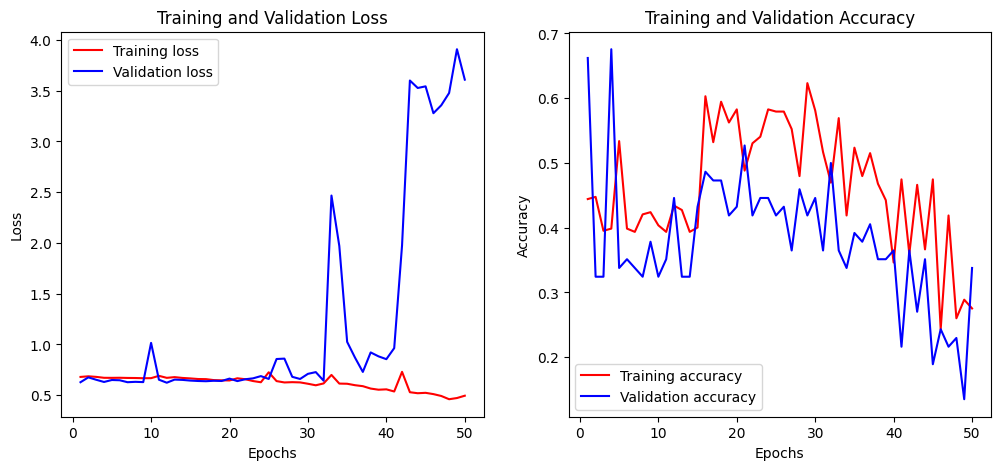

In [71]:
import matplotlib.pyplot as plt

#plot results
epochs = range(1, num_epochs+1)
plt.figure(figsize=(12, 5))

#plot training and validation loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'r', label='Training loss')
plt.plot(epochs, val_losses, 'b', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

#plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, 'r', label='Training accuracy')
plt.plot(epochs, val_accs, 'b', label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

In [72]:
#===============
#evaluation function
#===============
def evaluate(preds, y_list):
    preds =torch.cat(preds)
    y_list = torch.cat(y_list)
    TP = ((preds == 1) & (y_list == 1)).float().sum().item()
    FP = ((preds == 1) & (y_list == 0)).float().sum().item()
    TN = ((preds == 0) & (y_list == 0)).float().sum().item()
    FN = ((preds == 0) & (y_list == 1)).float().sum().item()

    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-8)
    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    F1 = 2 * precision * recall / (precision + recall + 1e-8)

    return accuracy, precision, recall, F1

In [73]:
#===============
#test loop
#===============
test_loss = 0
test_acc = 0
preds = []
y_list = []
model.eval()
with torch.no_grad():
    for global_x, local_x, y in test_loader:
        global_x, local_x, y = global_x.to(device), local_x.to(device), y.to(device)

        pred = model(global_x, local_x)
        loss = criterion(pred.view(-1), y)

        preds.append(pred.view(-1).round().detach().cpu())
        y_list.append(y.detach().cpu())

        test_loss += loss.item() * y.size(0)
        test_acc += (pred.view(-1).round() == y).float().sum().item()

    test_loss /= len(test_loader.dataset)
    test_acc /= len(test_loader.dataset)

    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

#evaluate the model
accuracy, precision, recall, F1 = evaluate(preds, y_list)
print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {F1:.4f}")

Test Loss: 0.9671, Test Accuracy: 0.2568
Accuracy: 0.4419, Precision: 0.4400, Recall: 0.5238, F1: 0.4783
